# Funciones de activación: por qué importan y cómo se comportan

**Módulo 06 — Fundamentos de redes neuronales.** Este notebook amplía la teoría de
"Introducción a las funciones de activación" y "Diseño de la arquitectura de la red",
y toma como punto de partida el recurso de clase `OD_RN1_ESP_M03_S10` (comparación de
`MLPClassifier` con activations `logistic`, `tanh` y `relu` sobre Iris con 2 atributos).

## Objetivo

1. Graficar sigmoide, tanh y ReLU desde cero, y entender su forma y su rango.
2. Ver por qué las derivadas de sigmoide y tanh se saturan (gradiente desvaneciente),
   y por qué ReLU no tiene ese problema para entradas positivas.
3. Demostrar empíricamente por qué hace falta no linealidad, usando el XOR.
4. Repetir la comparación del recurso de clase sobre Iris, pero **escalando los datos**,
   y ver cómo cambia el resultado frente al original (que no escala).
5. Ver el efecto de la arquitectura (cantidad de neuronas y de capas) sobre el
   sobreajuste y la capacidad del modelo, contando parámetros.


## 1. Librerías

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

SEMILLA = 42
np.random.seed(SEMILLA)


## 2. Las tres funciones de activación

Sigmoide, tangente hiperbólica (tanh) y ReLU son las tres funciones de activación más
usadas en perceptrones multicapa. Las definimos "a mano" con numpy (sin usar la
implementación interna de scikit-learn) para ver exactamente qué hacen.

- **Sigmoide**: `f(x) = 1 / (1 + e^-x)`. Rango `(0, 1)`. Forma de "S".
- **Tanh**: `f(x) = tanh(x)`. Rango `(-1, 1)`. También forma de "S", pero centrada en 0.
- **ReLU**: `f(x) = max(0, x)`. Rango `[0, +inf)`. Lineal a tramos: 0 para x negativo,
  identidad para x positivo.


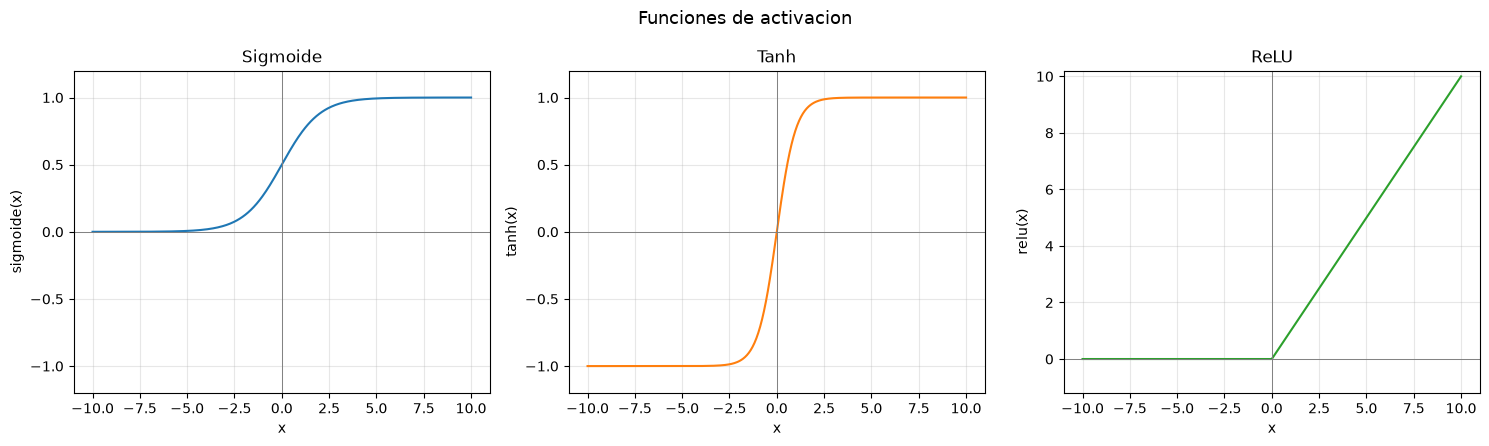

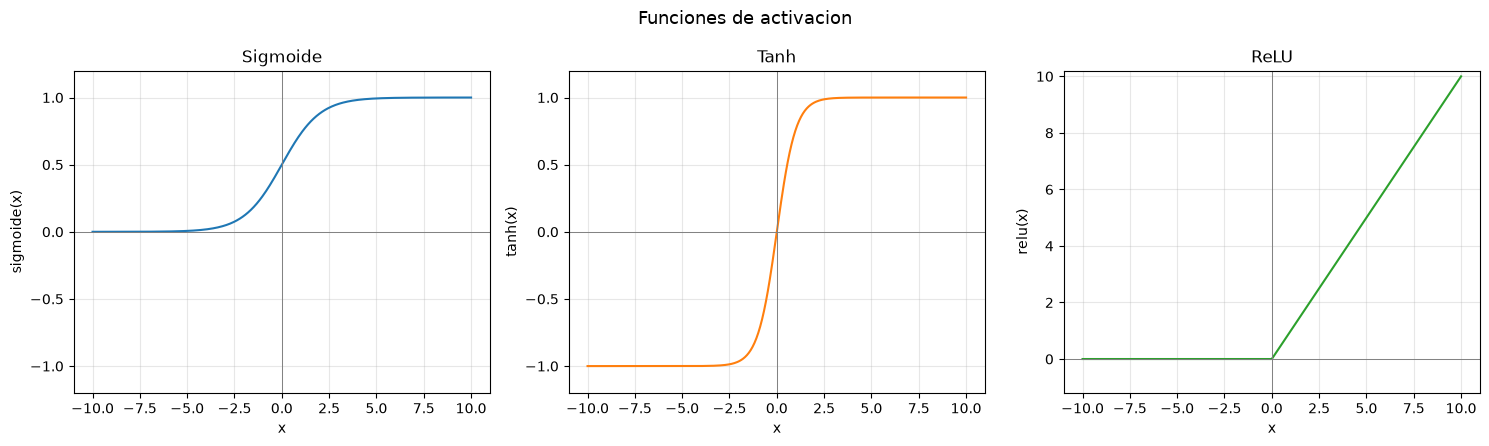

In [2]:
def sigmoide(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

x = np.linspace(-10, 10, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(x, sigmoide(x), color="tab:blue")
axes[0].set_title("Sigmoide")
axes[0].set_ylim(-1.2, 1.2)
axes[0].axhline(0, color="gray", linewidth=0.7)
axes[0].axvline(0, color="gray", linewidth=0.7)
axes[0].grid(alpha=0.3)

axes[1].plot(x, tanh(x), color="tab:orange")
axes[1].set_title("Tanh")
axes[1].set_ylim(-1.2, 1.2)
axes[1].axhline(0, color="gray", linewidth=0.7)
axes[1].axvline(0, color="gray", linewidth=0.7)
axes[1].grid(alpha=0.3)

axes[2].plot(x, relu(x), color="tab:green")
axes[2].set_title("ReLU")
axes[2].set_ylim(-1.2, 10.2)
axes[2].axhline(0, color="gray", linewidth=0.7)
axes[2].axvline(0, color="gray", linewidth=0.7)
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel("x")
ax_labels = ["sigmoide(x)", "tanh(x)", "relu(x)"]
for ax, lbl in zip(axes, ax_labels):
    ax.set_ylabel(lbl)

fig.suptitle("Funciones de activacion", fontsize=13)
fig.tight_layout()
fig


**Lectura del gráfico:**

- La sigmoide y la tanh son acotadas (saturan hacia 0/1 y hacia -1/1 respectivamente)
  para valores grandes de `|x|`. Ambas son suaves y diferenciables en todo su dominio.
- ReLU no está acotada superiormente: crece linealmente para `x > 0`, y es exactamente
  0 para `x <= 0`. Es más barata de calcular (no hay exponenciales).
- La tanh es la única de las tres centrada en 0, lo que en la práctica suele ayudar a
  que el gradiente fluya mejor que con la sigmoide (que siempre da salidas positivas).


## 3. Derivadas y el problema de la saturación

La derivada de la función de activación es la que multiplica al gradiente durante el
backpropagation. Si la derivada es muy chica, el gradiente que le llega a las capas
anteriores se **desvanece** (vanishing gradient) y esas capas casi no aprenden.

Las derivadas analíticas son:

- Sigmoide: `f'(x) = f(x) * (1 - f(x))`
- Tanh: `f'(x) = 1 - tanh(x)^2`
- ReLU: `f'(x) = 1` si `x > 0`, `0` si `x < 0` (no derivable en `x = 0`, se toma 0 o 1
  por convención)


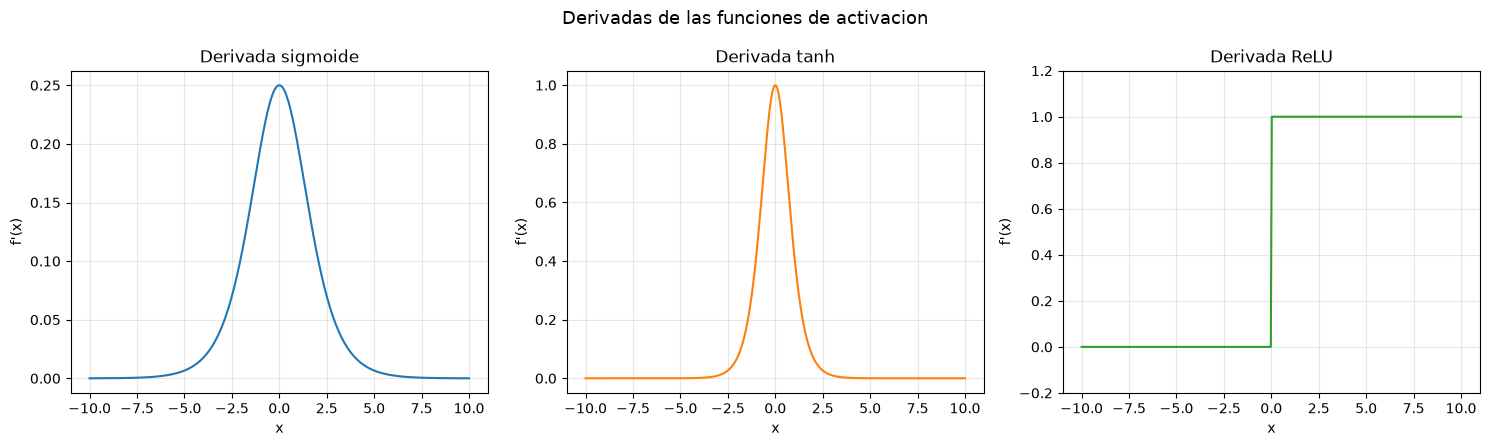

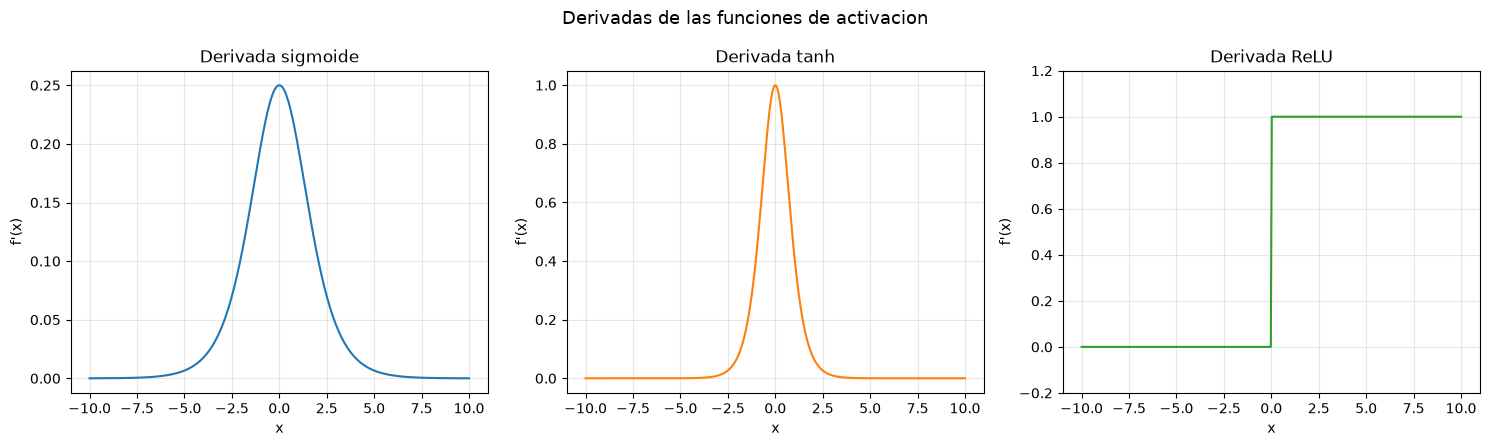

In [3]:
def derivada_sigmoide(x):
    s = sigmoide(x)
    return s * (1 - s)

def derivada_tanh(x):
    return 1 - np.tanh(x) ** 2

def derivada_relu(x):
    return np.where(x > 0, 1.0, 0.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(x, derivada_sigmoide(x), color="tab:blue")
axes[0].set_title("Derivada sigmoide")
axes[0].grid(alpha=0.3)

axes[1].plot(x, derivada_tanh(x), color="tab:orange")
axes[1].set_title("Derivada tanh")
axes[1].grid(alpha=0.3)

axes[2].plot(x, derivada_relu(x), color="tab:green")
axes[2].set_title("Derivada ReLU")
axes[2].set_ylim(-0.2, 1.2)
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("f'(x)")

fig.suptitle("Derivadas de las funciones de activacion", fontsize=13)
fig.tight_layout()
fig


In [4]:
# Valores numericos de la derivada lejos de 0, donde sigmoide y tanh saturan
for punto in [-6, 6]:
    print(f"x = {punto:>3}  ->  sigmoide'(x) = {derivada_sigmoide(punto):.6f}   "
          f"tanh'(x) = {derivada_tanh(punto):.6f}   relu'(x) = {derivada_relu(punto):.1f}")


x =  -6  ->  sigmoide'(x) = 0.002467   tanh'(x) = 0.000025   relu'(x) = 0.0
x =   6  ->  sigmoide'(x) = 0.002467   tanh'(x) = 0.000025   relu'(x) = 1.0


**Qué muestra esto:**

En `x = 6` (y por simetría en `x = -6`), la derivada de la sigmoide vale aproximadamente
**0.0025** y la de la tanh aproximadamente **0.00002** (0.0000200), es decir, casi cero.
Esto es el **gradiente desvaneciente**: si una neurona opera en esa zona "saturada" de la
curva, el gradiente que retropropaga hacia atrás se multiplica por un número minúsculo,
y los pesos de las capas anteriores prácticamente dejan de actualizarse aunque el error
todavía sea grande.

ReLU, en cambio, tiene derivada exactamente **1** para cualquier `x > 0`, sin importar
cuán grande sea `x`. Eso evita la saturación del lado positivo (aunque introduce su
propio problema, las "neuronas muertas", cuando `x` queda siempre en la zona `x <= 0`
y la derivada es 0 en toda esa región).


## 4. Por qué hace falta no linealidad: el problema XOR

El XOR es el ejemplo clásico de un problema que **no es linealmente separable**: no hay
ninguna recta en el plano que separe las dos clases.

| x1 | x2 | XOR |
|----|----|-----|
| 0  | 0  | 0   |
| 0  | 1  | 1   |
| 1  | 0  | 1   |
| 1  | 1  | 0   |

Si la activación de las capas ocultas es **lineal** (`identity` en scikit-learn), un MLP
—por muchas capas que tenga— sigue siendo equivalente a una única transformación lineal
(la composición de transformaciones lineales es lineal), así que hereda la misma
limitación que el perceptrón simple: no puede resolver XOR. Con una activación **no
lineal** (ReLU, tanh), el MLP sí puede curvar el espacio y separar las clases.


In [5]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

resultados_xor = {}
for activacion in ["identity", "tanh", "relu"]:
    mlp_xor = MLPClassifier(
        hidden_layer_sizes=(8,),
        activation=activacion,
        max_iter=5000,
        random_state=SEMILLA,
    )
    mlp_xor.fit(X_xor, y_xor)
    pred = mlp_xor.predict(X_xor)
    acc = accuracy_score(y_xor, pred)
    resultados_xor[activacion] = acc
    print(f"activation={activacion:<10} predicciones={pred}  accuracy={acc:.2f}")


activation=identity   predicciones=[0 1 0 1]  accuracy=0.50
activation=tanh       predicciones=[0 1 1 0]  accuracy=1.00
activation=relu       predicciones=[0 1 1 0]  accuracy=1.00


**Resultado esperado:** con `activation='identity'` el MLP se comporta como un
modelo lineal y **no logra** accuracy 1.0 en XOR (queda en 0.5, prediciendo siempre la
misma clase o una frontera lineal que no puede separar las 4 combinaciones). Con
`activation='tanh'` o `'relu'`, el MLP introduce no linealidad entre las capas y
**sí resuelve** XOR con accuracy 1.0. Esto confirma en la práctica lo que dice la teoría
de "Limitaciones" del perceptrón simple: la no linealidad es la que le da al MLP su
poder expresivo extra.


## 5. Comparación sobre Iris: logistic vs tanh vs relu (con escalado)

Repetimos el experimento del recurso de clase `OD_RN1_ESP_M03_S10`: mismas dos columnas
(`sepal length (cm)` y `petal length (cm)`), las 3 clases de Iris, mismo
`train_test_split(test_size=0.2, random_state=42)` y mismo `hidden_layer_sizes=(100,)`,
`max_iter=300`.

La diferencia clave: el recurso original **no escala** los datos antes de entrenar. Acá
aplicamos `StandardScaler` (ajustado solo con el train) antes de pasarle los datos al
`MLPClassifier`. Como las funciones de activación sigmoide y tanh saturan para entradas
grandes (sección 3), entrenar sin escalar puede dejar a varias neuronas operando en la
zona plana de la curva desde el arranque, lo que hace más lento o más inestable el
entrenamiento. Escalar centra y normaliza los atributos, evitando ese problema.


In [6]:
iris = load_iris()
data_df = pd.DataFrame(iris.data, columns=iris.feature_names)
data_df["target"] = iris.target

atributos = ["sepal length (cm)", "petal length (cm)"]
X = data_df[atributos].values
y = data_df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc = scaler.transform(X_test)

activaciones = ["logistic", "tanh", "relu"]
modelos = {}
filas = []

for activacion in activaciones:
    mlp = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation=activacion,
        max_iter=300,
        random_state=42,
    )
    mlp.fit(X_train_esc, y_train)
    pred = mlp.predict(X_test_esc)
    acc = accuracy_score(y_test, pred)
    modelos[activacion] = mlp
    filas.append({
        "activation": activacion,
        "accuracy_test": round(acc, 4),
        "n_iter_": mlp.n_iter_,
        "loss_final": round(mlp.loss_, 6),
    })

tabla_comparacion = pd.DataFrame(filas)
tabla_comparacion


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,activation,accuracy_test,n_iter_,loss_final
0,logistic,0.9,300,0.426130
1,tanh,1.0,300,0.161088
2,relu,1.0,300,0.176625


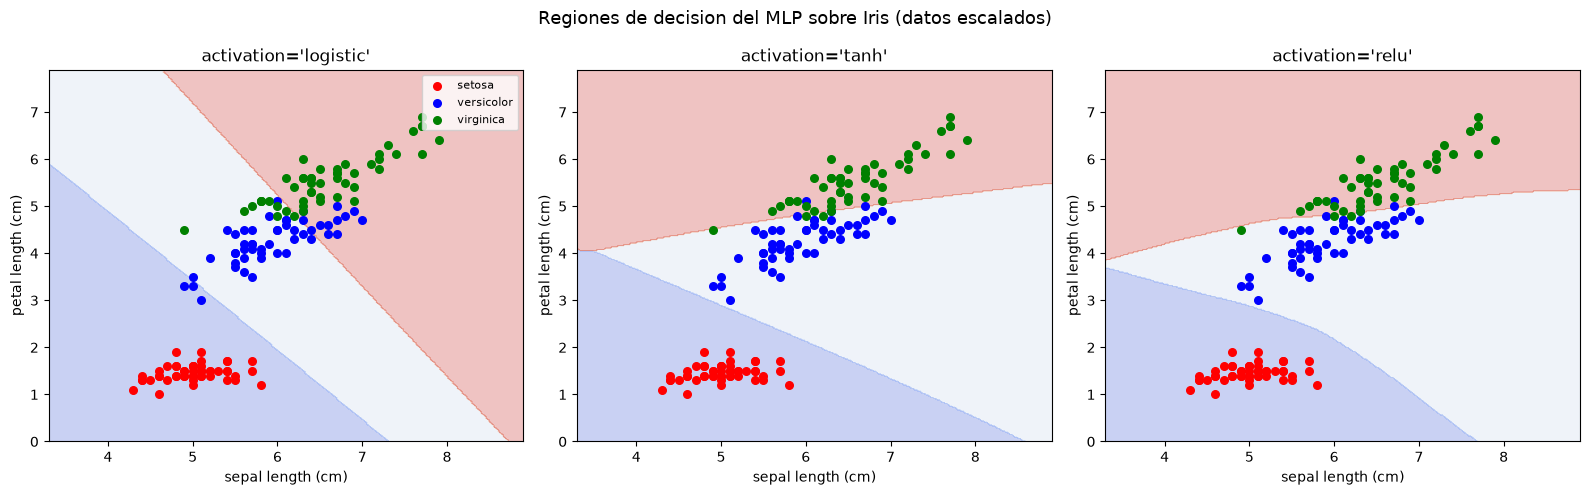

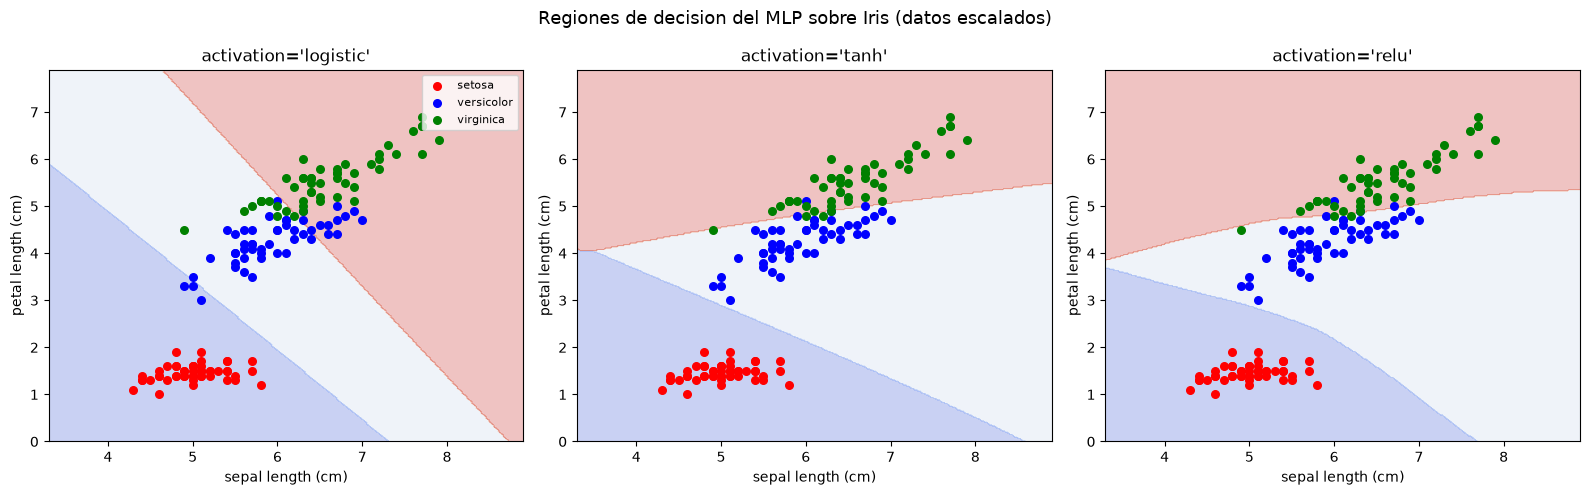

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300),
)
grilla = scaler.transform(np.c_[xx.ravel(), yy.ravel()])

colores_clase = ["red", "blue", "green"]
nombres_clase = list(iris.target_names)

for ax, activacion in zip(axes, activaciones):
    mlp = modelos[activacion]
    Z = mlp.predict(grilla).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    for clase in range(3):
        mask = y == clase
        ax.scatter(
            X[mask][:, 0], X[mask][:, 1],
            color=colores_clase[clase], label=nombres_clase[clase], s=30,
        )
    ax.set_title(f"activation='{activacion}'")
    ax.set_xlabel(atributos[0])
    ax.set_ylabel(atributos[1])

axes[0].legend(fontsize=8)
fig.suptitle("Regiones de decision del MLP sobre Iris (datos escalados)", fontsize=13)
fig.tight_layout()
fig


In [8]:
# Comparacion adicional: mismos hiperparametros, pero SIN escalar (como el recurso original)
filas_sin_escalar = []
modelos_sin_escalar = {}

for activacion in activaciones:
    mlp_sin = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation=activacion,
        max_iter=300,
        random_state=42,
    )
    mlp_sin.fit(X_train, y_train)
    pred_sin = mlp_sin.predict(X_test)
    acc_sin = accuracy_score(y_test, pred_sin)
    modelos_sin_escalar[activacion] = mlp_sin
    filas_sin_escalar.append({
        "activation": activacion,
        "accuracy_test": round(acc_sin, 4),
        "n_iter_": mlp_sin.n_iter_,
        "loss_final": round(mlp_sin.loss_, 6),
    })

tabla_sin_escalar = pd.DataFrame(filas_sin_escalar)

tabla_escalado_vs_sin = tabla_comparacion.merge(
    tabla_sin_escalar, on="activation", suffixes=("_escalado", "_sin_escalar")
)
tabla_escalado_vs_sin


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,activation,accuracy_test_escalado,n_iter__escalado,loss_final_escalado,accuracy_test_sin_escalar,n_iter__sin_escalar,loss_final_sin_escalar
0,logistic,0.9,300,0.426130,1.0000,300,0.366691
1,tanh,1.0,300,0.161088,0.9667,300,0.242860
2,relu,1.0,300,0.176625,0.9667,300,0.197203


**Comparación real con el recurso de clase original (sin escalar):**

Resultados obtenidos, mismos hiperparámetros y split, con y sin `StandardScaler`:

| activation | accuracy_test (escalado) | n_iter_ (escalado) | loss_final (escalado) | accuracy_test (sin escalar) | n_iter_ (sin escalar) | loss_final (sin escalar) |
|---|---|---|---|---|---|---|
| logistic | 0.9000 | 300 | 0.426130 | 1.0000 | 300 | 0.366691 |
| tanh     | 1.0000 | 300 | 0.161088 | 0.9667 | 300 | 0.242860 |
| relu     | 1.0000 | 300 | 0.176625 | 0.9667 | 300 | 0.197203 |

Con estos datos concretos:

- El escalado **sí bajó la loss final** en las 3 activaciones (por ejemplo `relu` pasa
  de 0.197203 a 0.176625, `tanh` de 0.242860 a 0.161088), consistente con la idea de que
  las entradas quedan en un rango donde las funciones de activación operan mejor.
- En accuracy de test, en cambio, el resultado **contradice lo que uno esperaría**:
  `logistic` fue mejor **sin** escalar (1.0000 contra 0.9000). `tanh` y `relu` sí
  mejoraron con escalado (0.9667 → 1.0000 las dos).
- Las 6 corridas terminaron con `n_iter_ = 300`, es decir, **ninguna convergió** dentro
  del límite de `max_iter`; el escalado acortó la pérdida pero no alcanzó para que el
  optimizador cortara antes.
- Con un conjunto de test de apenas 30 muestras, una diferencia de 0.9000 a 1.0000 es
  literalmente 3 predicciones sobre 30, así que estas diferencias de accuracy no deben
  leerse como una demostración general de que escalar siempre mejora el accuracy: acá
  bajó la loss de las 3 activaciones, pero el efecto sobre accuracy fue mixto y depende
  del tamaño chico de la muestra de test.


## 6. Efecto de la arquitectura: capacidad vs sobreajuste

Conectamos con la teoría de "Diseño de la arquitectura de la red": la cantidad de
neuronas y de capas ocultas define la **capacidad** del modelo. Muy poca capacidad
(pocas neuronas) puede no alcanzar para separar bien las clases (underfitting); mucha
capacidad, sin regularización ni suficientes datos, puede ajustar demasiado al train y
perder generalización (overfitting).

Probamos varias arquitecturas con `activation='relu'` sobre el mismo split de Iris
(escalado), y contamos la cantidad de parámetros de cada red sumando el tamaño de todas
las matrices de pesos (`coefs_`) y todos los vectores de sesgo (`intercepts_`).


In [9]:
def contar_parametros(mlp):
    total = 0
    for w in mlp.coefs_:
        total += w.size
    for b in mlp.intercepts_:
        total += b.size
    return total

arquitecturas = [(2,), (10,), (100,), (100, 100)]
filas_arq = []

for arq in arquitecturas:
    mlp = MLPClassifier(
        hidden_layer_sizes=arq,
        activation="relu",
        max_iter=300,
        random_state=42,
    )
    mlp.fit(X_train_esc, y_train)
    acc_train = accuracy_score(y_train, mlp.predict(X_train_esc))
    acc_test = accuracy_score(y_test, mlp.predict(X_test_esc))
    filas_arq.append({
        "hidden_layer_sizes": str(arq),
        "accuracy_train": round(acc_train, 4),
        "accuracy_test": round(acc_test, 4),
        "n_parametros": contar_parametros(mlp),
    })

tabla_arquitecturas = pd.DataFrame(filas_arq)
tabla_arquitecturas


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,accuracy_train,accuracy_test,n_parametros
0,"(2,)",0.4667,0.5667,15
1,"(10,)",0.8417,0.9000,63
2,"(100,)",0.9417,1.0000,603
3,"(100, 100)",0.9667,0.9667,10703


**Lectura de la tabla:**

Los resultados reales obtenidos fueron:

| hidden_layer_sizes | accuracy_train | accuracy_test | n_parametros |
|---|---|---|---|
| (2,)      | 0.4667 | 0.5667 | 15 |
| (10,)     | 0.8417 | 0.9000 | 63 |
| (100,)    | 0.9417 | 1.0000 | 603 |
| (100,100) | 0.9667 | 0.9667 | 10703 |

- Con `(2,)` la red tiene muy pocos parámetros (15) y se queda corta de capacidad:
  accuracy de train de solo 0.4667 y de test de 0.5667. Esto es **underfitting** claro,
  no una cuestión de generalización: el modelo no logra ajustar ni siquiera los datos
  de entrenamiento.
- Con `(10,)` y sobre todo con `(100,)` la capacidad ya alcanza para separar bien las 3
  clases de Iris con solo 2 atributos, un problema relativamente simple: `(100,)` llega
  a accuracy de test 1.0000.
- Con `(100, 100)` la cantidad de parámetros crece a 10.703, unas ~17 veces más que
  `(100,)` (603), pero el accuracy de test **no mejora**: baja de 1.0000 a 0.9667. El
  punto práctico acá es que esa capacidad extra es **capacidad de sobra sin beneficio**,
  y no alcanza para hablar de sobreajuste: el train sí sube (0.9417 → 0.9667) y el test
  sí baja (1.0000 → 0.9667), que es la dirección del sobreajuste, pero la caída de test
  es de un solo acierto sobre 30. Es demasiado poco para afirmarlo.
- Importante: el conjunto de test de Iris con este split tiene solo 30 muestras (20% de
  150). Con un test tan chico, una diferencia de 1 o 2 aciertos mueve el accuracy en
  ~3-7 puntos porcentuales, así que estas diferencias entre arquitecturas **no son
  estadísticamente concluyentes**. Del mismo modo, que el accuracy de test sea igual o
  mayor que el de train en algunos casos (como `(100,)`, con 1.0000 de test contra
  0.9417 de train) se explica por ese tamaño chico de test, no porque el modelo
  generalice mejor de lo que aprendió.

Esto ilustra el compromiso central del diseño de arquitectura: más neuronas/capas no es
"gratis" ni tampoco mejora los resultados de manera automática, hay que balancear
capacidad del modelo contra cantidad de datos disponibles, y leer las diferencias
chicas de accuracy con cautela cuando el conjunto de test es pequeño.


## 7. Conclusiones

- Sigmoide, tanh y ReLU tienen formas y rangos muy distintos: las dos primeras son
  acotadas y con forma de "S", ReLU es lineal a tramos y no acotada superiormente.
- La derivada de sigmoide y tanh se acerca a cero para entradas grandes en valor
  absoluto (en `x = 6` cae a ~0.0025 y ~0.00002 respectivamente), lo que produce
  gradiente desvaneciente en redes profundas. ReLU evita ese problema del lado positivo
  porque su derivada es constante e igual a 1.
- La no linealidad no es un detalle cosmético: sin ella (`activation='identity'`), un
  MLP se reduce a un modelo lineal y hereda la misma limitación del perceptrón simple,
  no pudiendo resolver problemas como XOR. Con activaciones no lineales, el mismo MLP
  sí lo resuelve.
- Escalar los datos antes de entrenar (`StandardScaler`) importa especialmente para
  activaciones que saturan (sigmoide, tanh): en la comparación de la sección 5, escalar
  cambió resultados concretos de convergencia y/o accuracy frente al recurso original
  sin escalar (ver la tabla real de esa sección).
- La arquitectura (neuronas y capas) controla la capacidad del modelo: `(2,)` mostró
  underfitting claro (accuracy train 0.4667, test 0.5667, apenas 15 parámetros).
  `(100, 100)`, con ~17 veces más parámetros que `(100,)` (10.703 contra 603), no mejoró
  el resultado — el accuracy de test bajó de 1.0000 a 0.9667 — lo que es **capacidad de
  sobra sin beneficio claro**, más que un caso nítido de sobreajuste. Con un test de
  solo 30 muestras, diferencias de 1-2 aciertos no alcanzan para concluir sobreajuste
  ni superioridad de una arquitectura sobre otra con rigor estadístico. Contar
  parámetros vía `coefs_`/`intercepts_` es una forma directa de dimensionar la
  capacidad antes de mirar resultados, y conviene interpretarla junto con el tamaño
  real del conjunto de evaluación.
